<a href="https://colab.research.google.com/github/AshleyH2026/A03-knn/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?

Regression predicts a numeric value, whereas classification predicts a category or group. A regression would compute the distance of every observed x, selet the k nearest observations, then average their outcomes. A classification would find the k nearest neighbors then estimate each class proportion by dividing neighbor count by k to predict the most common class.


2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table counts predictions by actual class and predicted class. By counting correct predictions and missclassifications, it can help us understand how accurate the model is and where the model is underperforming.

3. What does the SSE quantify about a particular model?

The sum of squared error, which adds squared residuals from validation observations, shows us the amount of error in the validation set. A lower SSE means less error.

4. What are overfitting and underfitting?

Overfitting and underfitting both relate to what predictions the model outputs. Overrfitting means the model's predictions are too detailed and thus more subject to noise in the data (results from a smaller k value). Underfitting means the model's predictions are too broad, to the point where they give nearly the same prediction for every observation or instance (results from a smaller k).

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

We split the data into training and testing sets so that we can see how well the model predicts new observations it hasn't seen before. By separating the data it trains on and giving it new data to use for the testing portion, you get a better sense of the model's predictive ability, so it isn't just remembering the correct answer. We can then use the validation data to determine which k to use. The k can improve model performance by avoiding overfitting and underfitting, and finding a good balance between not too much detail (to prevent noise) and enough detail for an accurate prediction. The SSE also helps us determine error with the model so we can further improve the model or consider certain limitationz

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Just reporting a class label as a prediction can be better for more simplified results that are easier to read or intepret because a prediction must fall into one class label. However, this could result in a loss of nuance and could result in unsure predictions or classifications being displayed as more confident ones. Whereas a prediction or a probability distribution over class labels allows for a more nuanced result, though it may be more difficult to interpret and form conclusions.



**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ashley Hughes

**Date:** 10/2/2026

1. EDA & summary of target label and features:

Mine Type Historgram



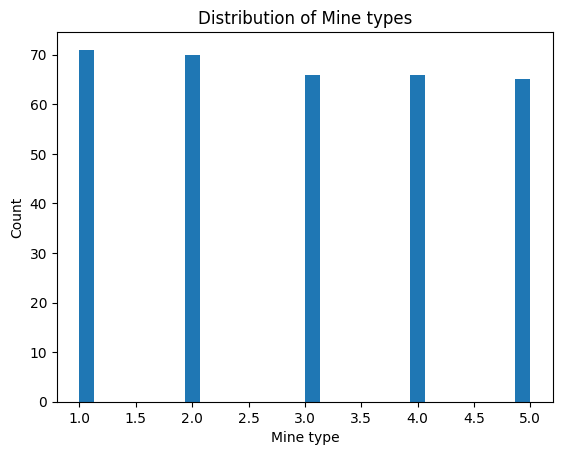

mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


Voltage, height, and soil historgrams (to see distributions and skewness)



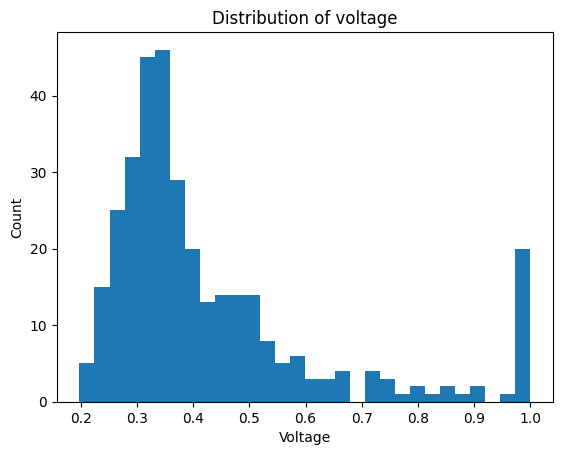

,mean,median,mode,Q1,Q3,max,min
0,0.431,0.36,1.0,0.31,0.483,1.0,0.198


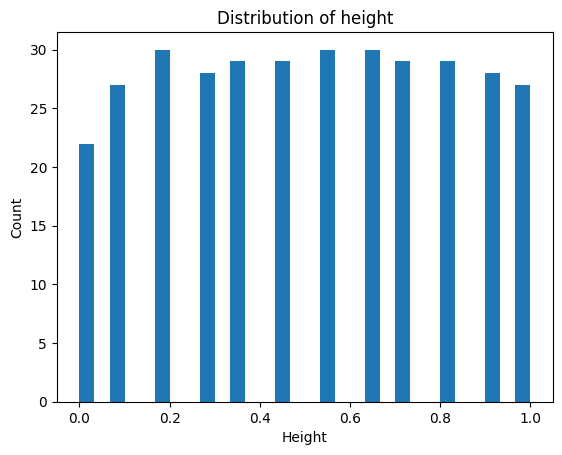

,mean,median,mode,Q1,Q3,max,min
0,0.509,0.545,0.182,0.273,0.727,1.0,0.0


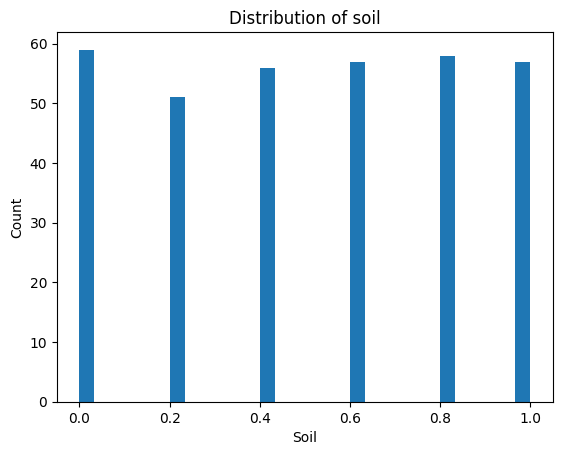

,mean,median,mode,Q1,Q3,max,min
0,0.504,0.6,0.0,0.2,0.8,1.0,0.0





There was a fairly even distribution between the different mine types. There is a slight right skew with more mine types 1 and 2, but overall uniform.

For the voltage histogram, it is right skewed with a sizable amount of outliers at 1, though the skew is not extreme enough to require further adjustment of the data (sinh or log.
The distributions for height and soil are also fairly uniform, with height being a bit less concentrated and the extreme high and low values.
Considering these distributions, we may move forward with observing relationships between the mine type and its features more directly.

Kernel Density Plots of Mine Type conditional on voltage, height and soil (separately)

KDE plot of voltage conditional on mine type:



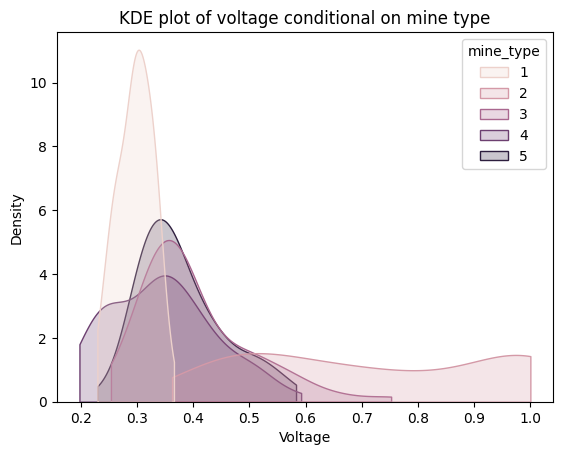



KDE plot of height conditional on mine type:



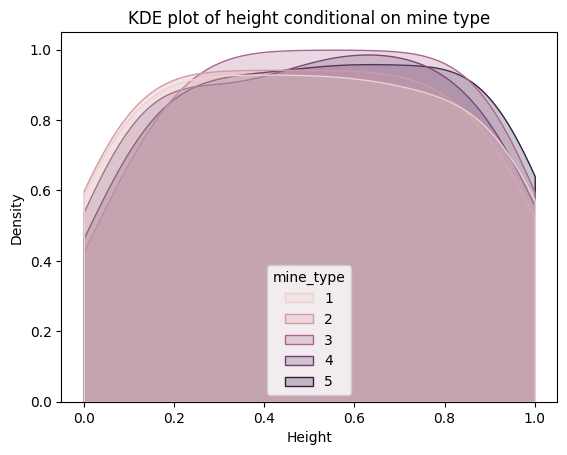



KDE plot of soil conditional on mine type:



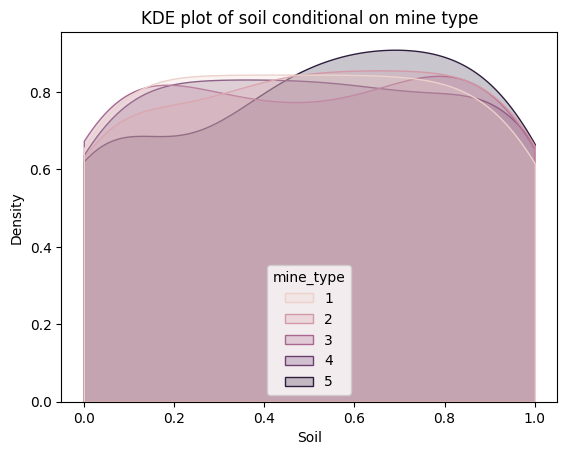



Summary:
The voltage kde conditional on mine type, displays a strong concentration of voltages between 0.24 and 0.36 belonging to mine type 1. 
There is a wider distribution for mine types 3, 4, and 5, with these having more similar distributions for voltage - especially types 3 and 5. 
The most unique voltage distribution was mine type 2, which has a very wide range of voltages that it could be.

The height kde conditional on mine type displays a very similar distribution among all of the different mine types, making them difficult to distinguish between them. 
Perhaps running a log function on them to make their differences more pronounced?

The soil kde conditional on mine type also displays a very similar distribution across the different mine types, though not as similar as the one for height. 


2. Split data sample 50/50 into training and test/validation sets

k-NN classifier
Best k: 1
Lowest validation SSE: 497
The k I will select is 1 because it is the k that yields the lowe

In [49]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

df = pd.read_csv('land_mines.csv')

print("1. EDA & summary of target label and features:\n")

print("Mine Type Historgram\n")
mine_type = df['mine_type']
df['mine_type'].hist(bins=30, grid=False)
plt.title("Distribution of Mine types")
plt.xlabel("Mine type")
plt.ylabel("Count")
plt.show()

mine_value_counts = df['mine_type'].value_counts(normalize = True)
print(mine_value_counts)

print("\n")

print("Voltage, height, and soil historgrams (to see distributions and skewness)\n")
voltage = df['voltage']
df['voltage'].hist(bins=30, grid=False)
plt.title("Distribution of voltage")
plt.xlabel("Voltage")
plt.ylabel("Count")
plt.show()

voltage_summary = pd.DataFrame({
    "mean": [df["voltage"].mean()],
    "median": [df["voltage"].median()],
    "mode": [df["voltage"].mode().iloc[0]],
    "Q1": [df["voltage"].quantile(0.25)],
    "Q3": [df["voltage"].quantile(0.75)],
    "max": [df["voltage"].max()],
    "min": [df["voltage"].min()],
})

display(voltage_summary.round(3))

print("\n")

height = df['height']
df['height'].hist(bins=30, grid=False)
plt.title("Distribution of height")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

height_summary = pd.DataFrame({
    "mean": [df["height"].mean()],
    "median": [df["height"].median()],
    "mode": [df["height"].mode().iloc[0]],
    "Q1": [df["height"].quantile(0.25)],
    "Q3": [df["height"].quantile(0.75)],
    "max": [df["height"].max()],
    "min": [df["height"].min()],
})

display(height_summary.round(3))

print("\n")

soil = df['soil']
df['soil'].hist(bins=30, grid=False)
plt.title("Distribution of soil")
plt.xlabel("Soil")
plt.ylabel("Count")
plt.show()
soil_summary = pd.DataFrame({
    "mean": [df["soil"].mean()],
    "median": [df["soil"].median()],
    "mode": [df["soil"].mode().iloc[0]],
    "Q1": [df["soil"].quantile(0.25)],
    "Q3": [df["soil"].quantile(0.75)],
    "max": [df["soil"].max()],
    "min": [df["soil"].min()],
})

display(soil_summary.round(3))

print("\n")

print("""
There was a fairly even distribution between the different mine types. There is a slight right skew with more mine types 1 and 2, but overall uniform.

For the voltage histogram, it is right skewed with a sizable amount of outliers at 1, though the skew is not extreme enough to require further adjustment of the data (sinh or log.
The distributions for height and soil are also fairly uniform, with height being a bit less concentrated and the extreme high and low values.
Considering these distributions, we may move forward with observing relationships between the mine type and its features more directly.
""")

print("Kernel Density Plots of Mine Type conditional on voltage, height and soil (separately)\n")

print('KDE plot of voltage conditional on mine type:\n')
sns.kdeplot(data = df, x='voltage', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of voltage conditional on mine type')
plt.xlabel('Voltage')
plt.show()
print('\n')

print('KDE plot of height conditional on mine type:\n')
sns.kdeplot(data = df, x='height', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of height conditional on mine type')
plt.xlabel('Height')
plt.show()
print('\n')

print('KDE plot of soil conditional on mine type:\n')
sns.kdeplot(data = df, x='soil', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of soil conditional on mine type')
plt.xlabel('Soil')
plt.show()
print('\n')

print("""Summary:
The voltage kde conditional on mine type, displays a strong concentration of voltages between 0.24 and 0.36 belonging to mine type 1.
There is a wider distribution for mine types 3, 4, and 5, with these having more similar distributions for voltage - especially types 3 and 5.
The most unique voltage distribution was mine type 2, which has a very wide range of voltages that it could be.

The height kde conditional on mine type displays a very similar distribution among all of the different mine types, making them difficult to distinguish between them.
Perhaps running a log function on them to make their differences more pronounced?

The soil kde conditional on mine type also displays a very similar distribution across the different mine types, though not as similar as the one for height.

""")


print("2. Split data sample 50/50 into training and test/validation sets\n")

classification_X_raw = df[["voltage", "height", "soil"]]
classification_y = df["mine_type"]
classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=3).fit(
    classification_X_scaled, classification_y
)

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=55, stratify=eval_y
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

print("k-NN classifier")
eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
        (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
        (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

print("Best k:", eval_k_star)
print("Lowest validation SSE:", min(eval_valid_sse))
print("The k I will select is 1 because it is the k that yields the lowest SSE.")

print("\n")

print("Confusion table")
optimal_knn = KNeighborsClassifier(n_neighbors=eval_k_star)
optimal_knn.fit(eval_X_train_scaled, eval_y_train)
y_pred = optimal_knn.predict(eval_X_valid_scaled)

cm = confusion_matrix(eval_y_valid, y_pred)
print(cm)

print("Accuracy:" + str(accuracy_score(eval_y_valid, y_pred)*100))
print("""
The accuracy of the model is roughly 37%.
For mine type one, there were 12 that were type one correctly predicted as type one. 11 were predicted as type two, 4 as class 3, and eight as class 4.
For mine type two, 27 were correctly predicted type two, but 3 were incorrectly predicted as type two and 5 as type 4.
For mine type three, 8 were corectly predicted as type three, but 5 were predicted as type one, 6 as type 4, and 14 as type 5.
For mine type four, 9 were correctly predicted, while 24 were incorrectly predicted - most of them being mistaken for types one, three, and five.
For mine type five, 7 were correctly predicted, while the other were mistaken for types one, three, and five.
The most inaccurate predictions were for mine types three, four, and five.

These results are in line with what was seen displayed in the kde plots.
hen training the model, it would make sense that the model would be less accurate for mine types 3, 4 and 5,
and would be more accurate for mine type 2 (since values from 0.8-1 can only be type 2).
Also, because the voltage kde had the mot unique curves across mine types (compared to soil and height),
voltage was likely the main distinguisher between mine types, which is why the implications from the voltage kde appear so pronounced.
""")

print("""5.
The most accurate predictions appear to be for mine type two, so I would advise them to trust predictions for that mine type over the others.
For the other mine types, the model was pretty hit or miss, so I would advise extra verification rather than taking the model's word for it.
This is likely due to the features between those four mine types not being very different from each other, causing the model to struggle to differentiate them.
Further advice to improve the model might consist of giving it more training data,
or finding a way to make the features which the model is predicting based on, more distinguishable.
""")


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]